# EDA & Feature Selection — Power Plant Water Consumption

**Target**: `consumption_ML` (observed annual water consumption in megaliters)  
**Source**: `Pre_Lasso_Data.csv` (2,002 rows × 32 columns)  

### Goals
1. Drop zero-variance and perfectly redundant columns immediately
2. Diagnose multicollinearity (VIF + correlation heatmap)
3. Understand the target distribution (log-transform check)
4. Test whether categorical variables carry statistically significant signal (Kruskal-Wallis)
5. Run a LASSO regularization path to identify which features survive shrinkage
6. Produce a justified, reduced feature set for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LassoCV, lasso_path
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = [12, 5]

DATA_PATH = Path('..') / 'data' / 'processed' / 'Pre_Lasso_Data_with_DryHybrid.csv'
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 2,251 rows × 33 columns


,plant_code,plant_name,year,state,net_gen_mwh,consumption_ML,withdrawal_ML,discharge_ML,facility_age_yrs,cooling_category,...,RH_oa_pct,P_oa_pa,state_water_intensity_L_per_MWh,estimated_WUE_liters_per_kwh,Simulated_Effectiveness,Simulated_WUE_Peak,Simulated_WUE_Mean,Simulated_WUE_Blended_10pct,Simulated_WUE_Blended_20pct,capacity_mw
0,1416,Arsenal Hill,2021,LA,44546.0,153.600582,8539.88496,53.904238,61,Closed,...,60.0,101325.0,986.692488,3.448134,3.506253,3.617522,3.425532,3.444731,3.463930,749.0
1,1416,Arsenal Hill,2024,LA,192057.0,646.707015,25402.34206,277.739317,64,Closed,...,60.0,101325.0,1142.398225,3.367266,3.528328,3.632243,3.432565,3.452533,3.472501,749.0
2,1416,Arsenal Hill,2023,LA,177828.0,627.223510,27634.99959,203.920037,63,Closed,...,60.0,101325.0,1027.933436,3.527136,3.529542,3.633082,3.431773,3.451904,3.472035,749.0


---
## 1. Column Audit — Immediate Drops

Before any analysis, remove columns that cannot carry information:
- **Zero-variance**: `RH_oa_pct` (hardcoded 60%) and `P_oa_pa` (hardcoded 101325 Pa) — identical value in every row, zero standard deviation
- **Perfect duplicate**: `T_oa_celsius` is a linear transformation of `max_temp_f` (r = 1.000) — one is redundant
- **Identifiers**: `plant_code`, `plant_name` — not predictive features

In [2]:
# Zero-variance check
num_df = df.select_dtypes('number')
zero_var = num_df.columns[num_df.std() == 0].tolist()
print('Zero-variance columns:', zero_var)
print(df[zero_var].describe())

Zero-variance columns: ['RH_oa_pct', 'P_oa_pa']
       RH_oa_pct   P_oa_pa
count     2251.0    2251.0
mean        60.0  101325.0
std          0.0       0.0
min         60.0  101325.0
25%         60.0  101325.0
50%         60.0  101325.0
75%         60.0  101325.0
max         60.0  101325.0


In [3]:
# Perfect collinearity: T_oa_celsius vs max_temp_f
print(f"r(T_oa_celsius, max_temp_f) = {df['T_oa_celsius'].corr(df['max_temp_f']):.6f}")
print(f"r(T_oa_celsius, mean_temp_f) = {df['T_oa_celsius'].corr(df['mean_temp_f']):.6f}")

r(T_oa_celsius, max_temp_f) = 0.936581
r(T_oa_celsius, mean_temp_f) = 0.903790


In [4]:
DROP_IMMEDIATELY = ['RH_oa_pct', 'P_oa_pa', 'T_oa_celsius', 'plant_code', 'plant_name']
df = df.drop(columns=DROP_IMMEDIATELY)
print(f'After immediate drops: {df.shape[1]} columns remain')
print(df.columns.tolist())

After immediate drops: 28 columns remain
['year', 'state', 'net_gen_mwh', 'consumption_ML', 'withdrawal_ML', 'discharge_ML', 'facility_age_yrs', 'cooling_category', 'cooling_type_eia', 'n_cooling_systems', 'primary_fuel', 'LAT', 'LON', 'ashrae_zone', 'moisture_regime', 'ba_climate_zone', 'bws_raw', 'max_temp_f', 'min_temp_f', 'mean_temp_f', 'state_water_intensity_L_per_MWh', 'estimated_WUE_liters_per_kwh', 'Simulated_Effectiveness', 'Simulated_WUE_Peak', 'Simulated_WUE_Mean', 'Simulated_WUE_Blended_10pct', 'Simulated_WUE_Blended_20pct', 'capacity_mw']


---
## 2. Target Variable Distribution

`consumption_ML` spans 0.03 to ~146,000 — extreme right skew. A log transform is almost certainly needed for linear models.

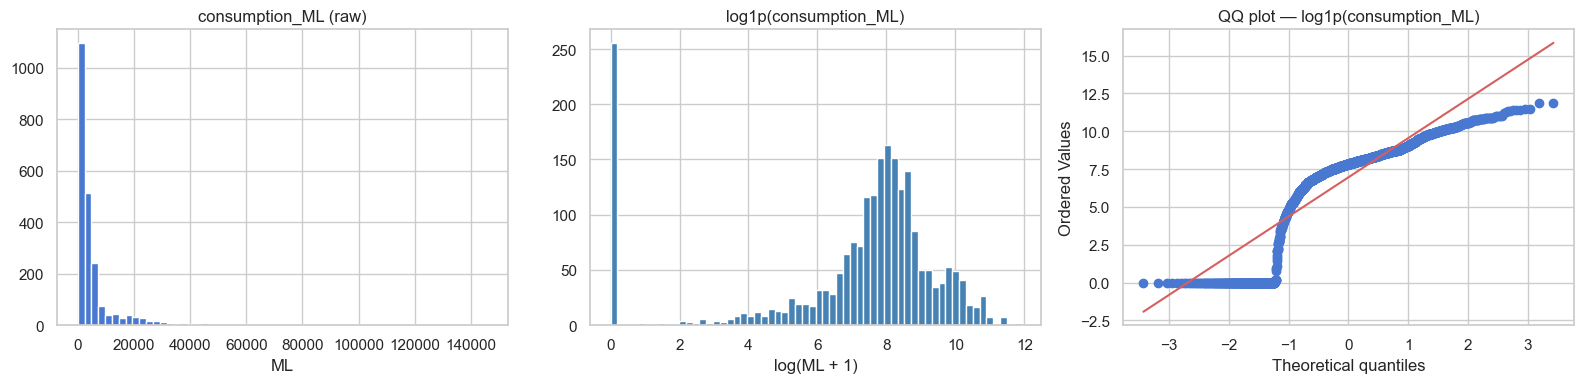

count      2251.000000
mean       5868.132733
std       11051.822218
min           0.000000
25%         755.965304
50%        2556.934678
75%        5498.718742
max      145978.280000
Name: consumption_ML, dtype: float64

Skewness (raw):      4.93
Skewness (log1p):    -1.43


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['consumption_ML'], bins=60, edgecolor='white')
axes[0].set_title('consumption_ML (raw)')
axes[0].set_xlabel('ML')

log_cons = np.log1p(df['consumption_ML'])
axes[1].hist(log_cons, bins=60, edgecolor='white', color='steelblue')
axes[1].set_title('log1p(consumption_ML)')
axes[1].set_xlabel('log(ML + 1)')

# QQ plot of log-transformed target
stats.probplot(log_cons, dist='norm', plot=axes[2])
axes[2].set_title('QQ plot — log1p(consumption_ML)')

plt.tight_layout()
plt.show()

print(df['consumption_ML'].describe())
print(f'\nSkewness (raw):      {df["consumption_ML"].skew():.2f}')
print(f'Skewness (log1p):    {log_cons.skew():.2f}')

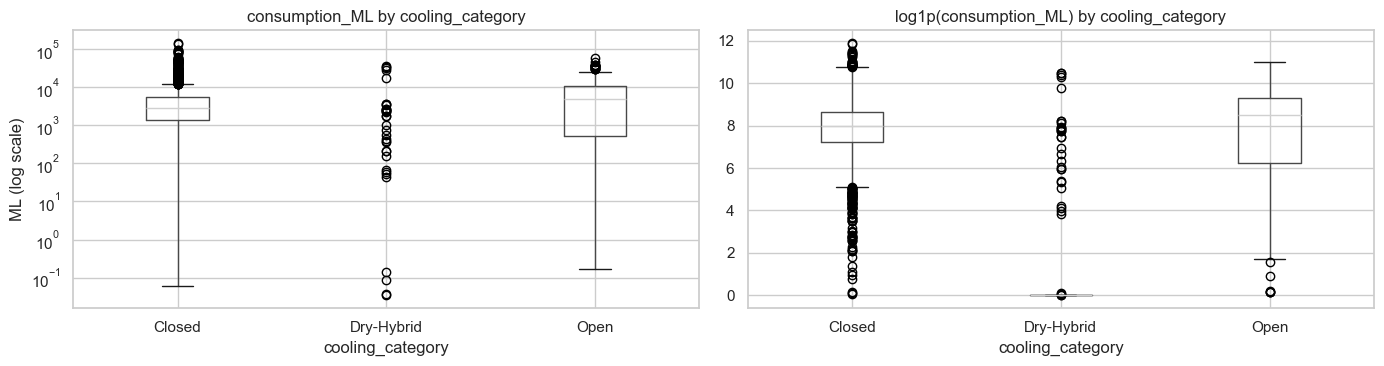

                   count    mean      std  min     25%     50%      75%  \
cooling_category                                                          
Closed            1752.0  6350.6  11595.3  0.1  1370.8  2921.6   5626.8   
Dry-Hybrid         278.0   668.1   4106.6  0.0     0.0     0.0      0.0   
Open               221.0  8584.4  10696.4  0.2   521.2  4932.4  10968.2   

                       max  
cooling_category            
Closed            145978.3  
Dry-Hybrid         36135.5  
Open               58503.5  


In [6]:
# Target by cooling category
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.boxplot(column='consumption_ML', by='cooling_category', ax=axes[0])
axes[0].set_title('consumption_ML by cooling_category')
axes[0].set_yscale('log')
axes[0].set_ylabel('ML (log scale)')

df['log_consumption'] = log_cons
df.boxplot(column='log_consumption', by='cooling_category', ax=axes[1])
axes[1].set_title('log1p(consumption_ML) by cooling_category')

plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('cooling_category')['consumption_ML'].describe().round(1))

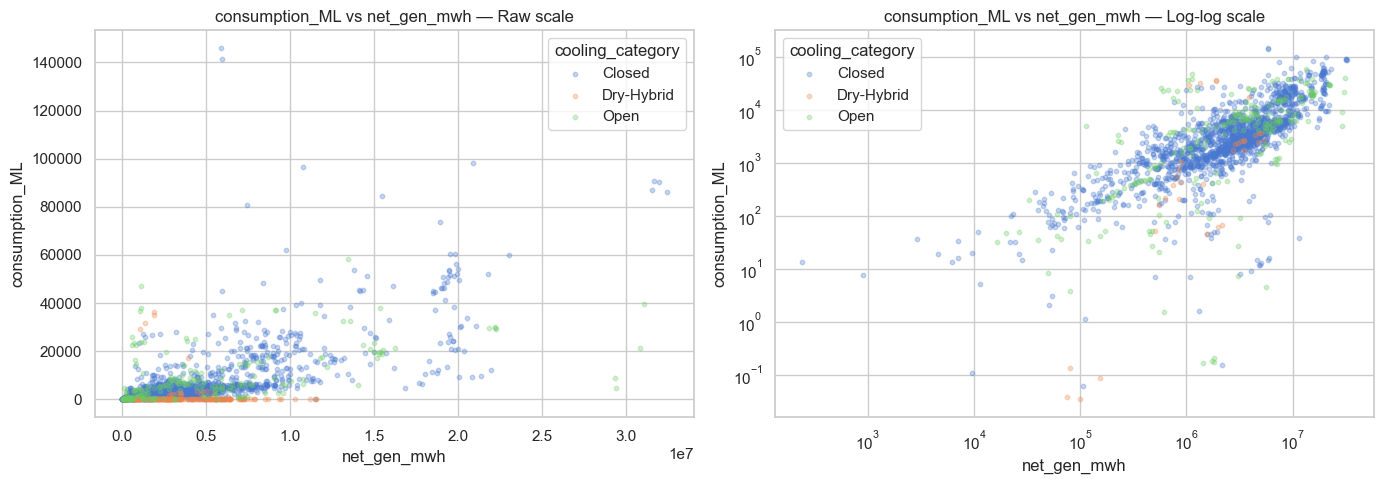

In [7]:
# Primary scatter: net_gen_mwh vs consumption_ML
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xscale, yscale, title in [
    (axes[0], 'linear', 'linear', 'Raw scale'),
    (axes[1], 'log',    'log',    'Log-log scale'),
]:
    for cat, grp in df.groupby('cooling_category'):
        ax.scatter(grp['net_gen_mwh'], grp['consumption_ML'], alpha=0.3, s=10, label=cat)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlabel('net_gen_mwh')
    ax.set_ylabel('consumption_ML')
    ax.set_title(f'consumption_ML vs net_gen_mwh — {title}')
    ax.legend(title='cooling_category')
plt.tight_layout()
plt.show()

---
## 3. Correlation Heatmap

Pearson and Spearman correlations between all numeric features and the (log-transformed) target.
Known multicollinearity group to watch: `max_temp_f`, `min_temp_f`, `mean_temp_f` (r > 0.97 with each other).

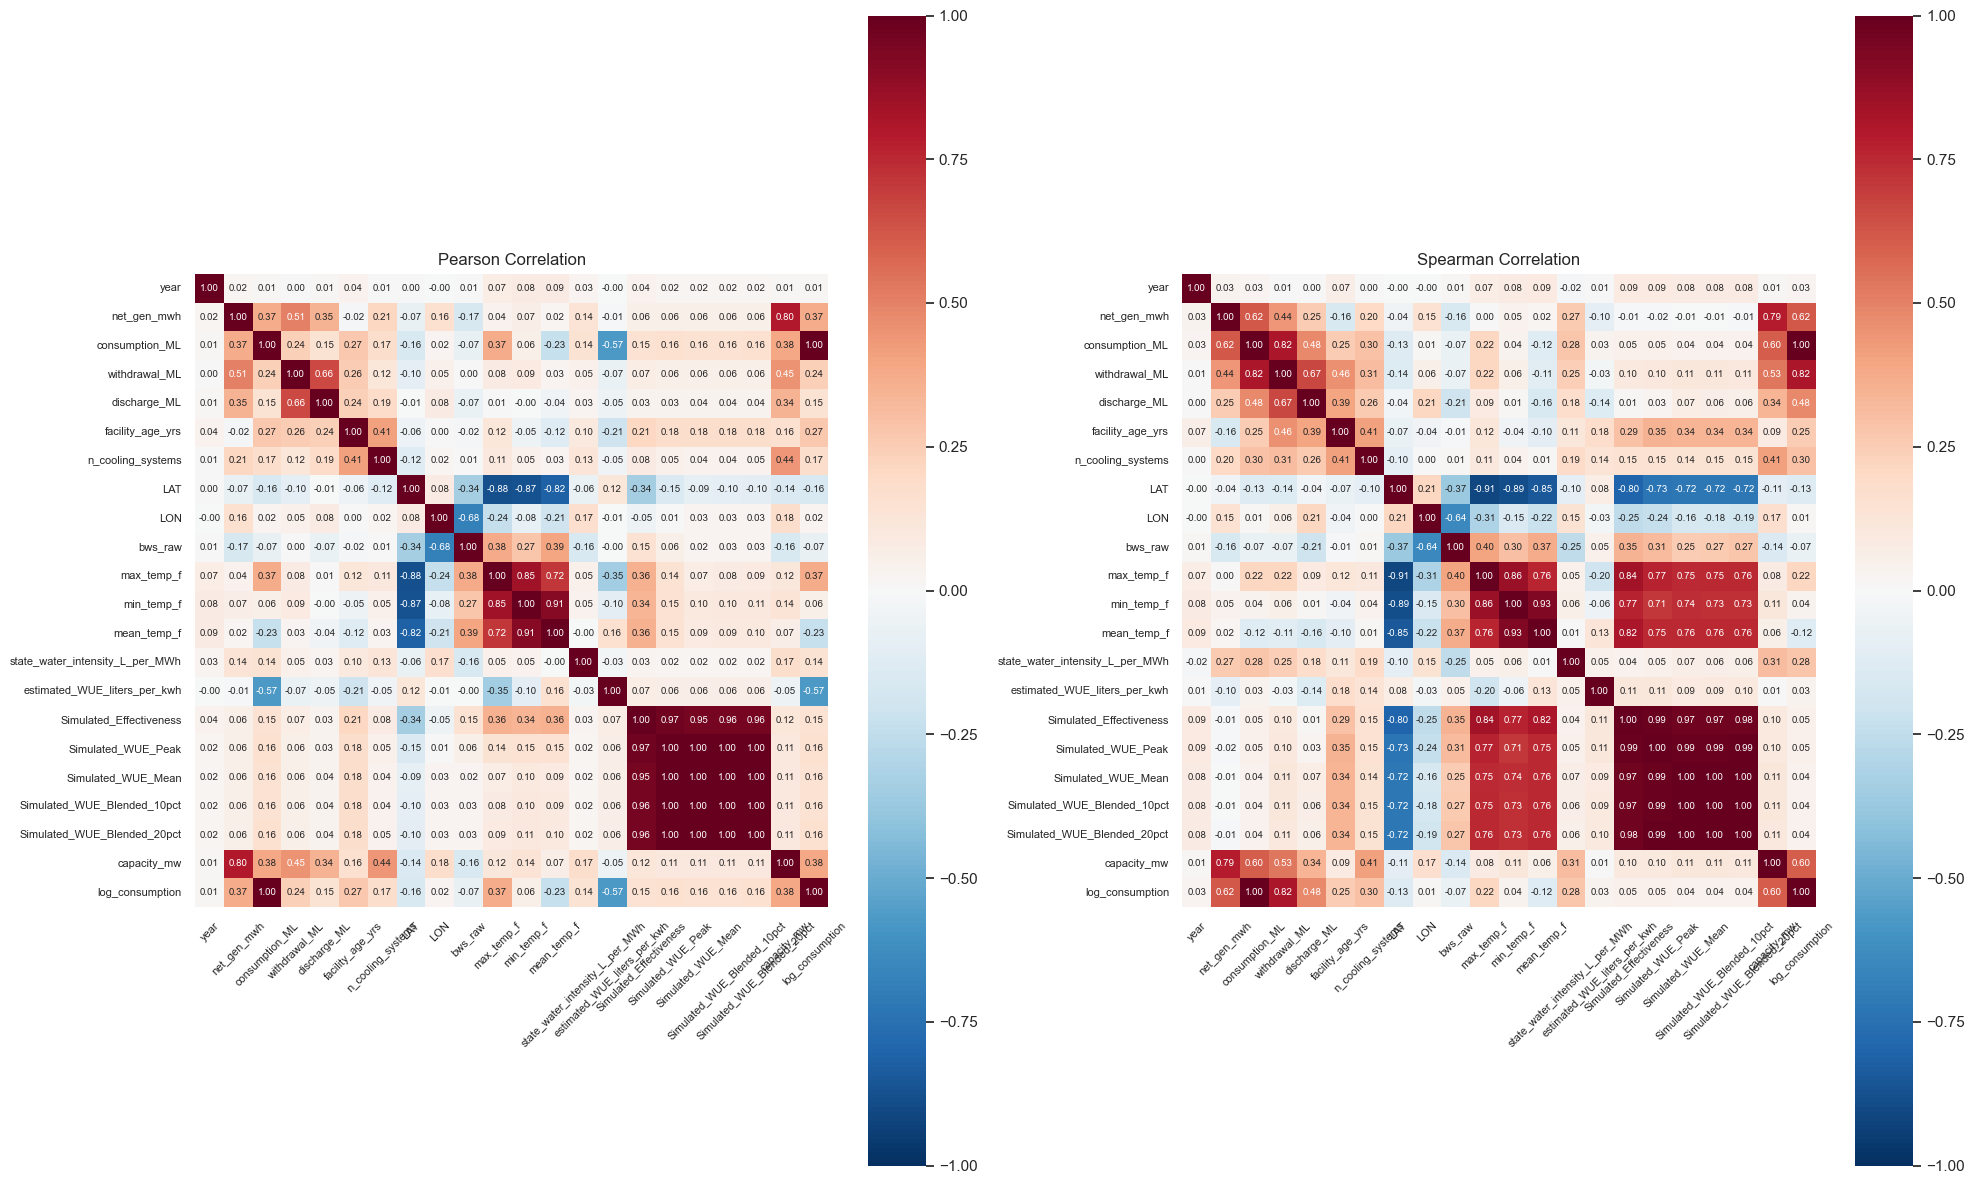

In [8]:
numeric_cols = df.select_dtypes('number').columns.tolist()
# Use log-transformed target for correlation
corr_df = df[numeric_cols].copy()
corr_df['consumption_ML'] = log_cons  # replace raw with log

pearson  = corr_df.corr(method='pearson')
spearman = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 12))
for ax, mat, title in [(axes[0], pearson, 'Pearson'), (axes[1], spearman, 'Spearman')]:
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, square=True,
                annot_kws={'size': 7})
    ax.set_title(f'{title} Correlation')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

In [9]:
# Correlations with target specifically (sorted)
target_corr = pearson['consumption_ML'].drop('consumption_ML').sort_values(key=abs, ascending=False)
print('Pearson |r| with log(consumption_ML):')
print(target_corr.round(3).to_string())
print()
target_corr_s = spearman['consumption_ML'].drop('consumption_ML').sort_values(key=abs, ascending=False)
print('Spearman |r| with log(consumption_ML):')
print(target_corr_s.round(3).to_string())

Pearson |r| with log(consumption_ML):
log_consumption                    1.000
estimated_WUE_liters_per_kwh      -0.573
capacity_mw                        0.384
net_gen_mwh                        0.373
max_temp_f                         0.369
facility_age_yrs                   0.267
withdrawal_ML                      0.240
mean_temp_f                       -0.227
n_cooling_systems                  0.173
Simulated_WUE_Peak                 0.157
LAT                               -0.156
Simulated_WUE_Blended_20pct        0.156
Simulated_WUE_Blended_10pct        0.156
Simulated_WUE_Mean                 0.156
Simulated_Effectiveness            0.155
discharge_ML                       0.148
state_water_intensity_L_per_MWh    0.141
bws_raw                           -0.075
min_temp_f                         0.055
LON                                0.024
year                               0.013

Spearman |r| with log(consumption_ML):
log_consumption                    1.000
withdrawal_ML       

---
## 4. Multicollinearity — Variance Inflation Factor (VIF)

VIF > 10 indicates severe multicollinearity. VIF > 5 is worth investigating.  
Expected high-VIF candidates: temp columns (r > 0.97), Simulated_WUE columns (r > 0.997).

                        feature          VIF
             Simulated_WUE_Peak          inf
    Simulated_WUE_Blended_20pct          inf
    Simulated_WUE_Blended_10pct          inf
             Simulated_WUE_Mean          inf
                    mean_temp_f 3.106837e+06
                     max_temp_f 1.095281e+06
                     min_temp_f 5.309304e+05
        Simulated_Effectiveness 3.086048e+04
                           year 8.564967e+03
                            LAT 5.761182e+02
                            LON 1.264735e+02
                    capacity_mw 1.078523e+01
               facility_age_yrs 9.424091e+00
              n_cooling_systems 7.195040e+00
                    net_gen_mwh 6.594601e+00
                        bws_raw 5.554074e+00
state_water_intensity_L_per_MWh 3.208601e+00
                  withdrawal_ML 2.636500e+00
                   discharge_ML 1.942798e+00
   estimated_WUE_liters_per_kwh 1.469411e+00


c:\Users\primo\StatLearnResearch\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\primo\StatLearnResearch\.venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


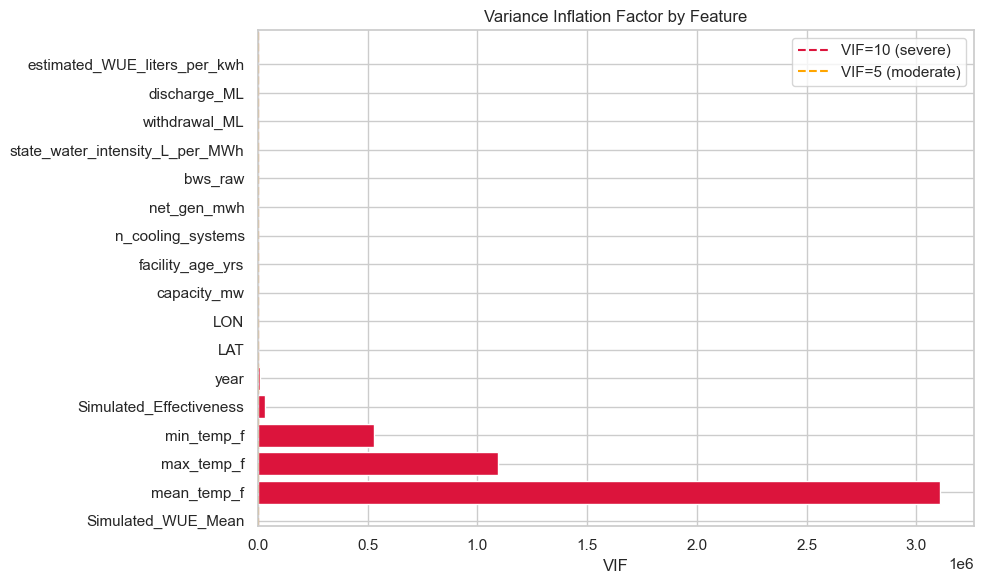

In [10]:
# VIF requires complete cases — drop rows with any NaN in numeric features
vif_cols = [c for c in numeric_cols if c not in ['consumption_ML', 'log_consumption']]
vif_data = df[vif_cols].dropna()

vif_results = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print(vif_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue' for v in vif_results['VIF']]
ax.barh(vif_results['feature'], vif_results['VIF'], color=colors)
ax.axvline(10, color='crimson', linestyle='--', label='VIF=10 (severe)')
ax.axvline(5, color='orange', linestyle='--', label='VIF=5 (moderate)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor by Feature')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Categorical Variable Significance — Kruskal-Wallis Test

Non-parametric test: does `consumption_ML` differ significantly across groups?  
H₀ = all groups have the same distribution. p < 0.05 → reject → the variable carries signal.

In [11]:
cat_cols = ['cooling_category', 'cooling_type_eia', 'primary_fuel',
            'ashrae_zone', 'moisture_regime', 'ba_climate_zone', 'state', 'year']

results = []
for col in cat_cols:
    groups = [grp['consumption_ML'].dropna().values
              for _, grp in df.groupby(col) if len(grp) > 1]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        n_groups = df[col].nunique()
        results.append({'feature': col, 'n_groups': n_groups, 'H_stat': round(stat, 2), 'p_value': p})

kw_df = pd.DataFrame(results).sort_values('p_value')
kw_df['significant'] = kw_df['p_value'] < 0.05
print(kw_df.to_string(index=False))

         feature  n_groups  H_stat       p_value  significant
cooling_type_eia         8  835.08 4.985649e-176         True
cooling_category         3  623.26 4.580489e-136         True
    primary_fuel        16  654.33 1.421951e-130         True
           state        48  526.23  9.146829e-83         True
     ashrae_zone        14  156.64  9.432546e-27         True
 ba_climate_zone         7  101.71  1.101869e-19         True
 moisture_regime         3   49.84  1.503903e-11         True
            year         4    1.54  6.740428e-01        False


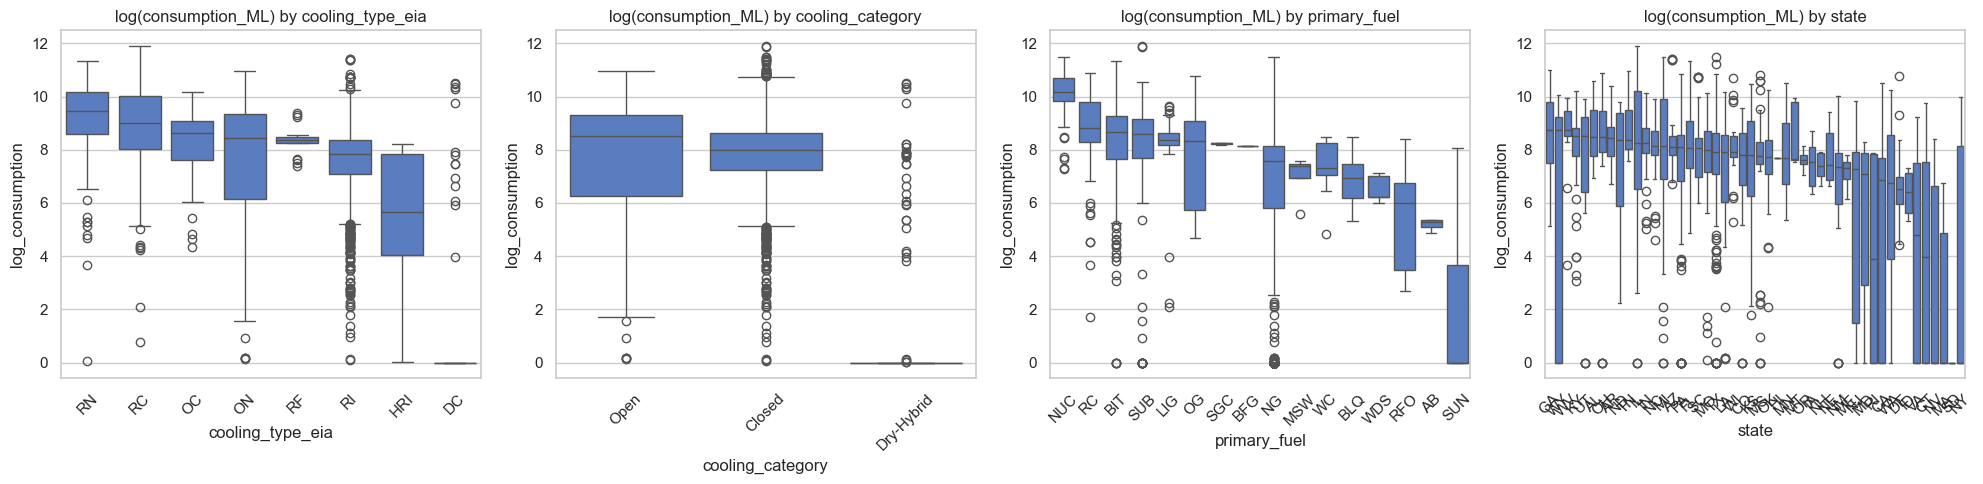

In [12]:
# Visualize top categorical variables
sig_cats = kw_df[kw_df['significant']]['feature'].tolist()[:4]
fig, axes = plt.subplots(1, len(sig_cats), figsize=(5 * len(sig_cats), 5))
if len(sig_cats) == 1:
    axes = [axes]
for ax, col in zip(axes, sig_cats):
    order = df.groupby(col)['consumption_ML'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='log_consumption', order=order, ax=ax)
    ax.set_title(f'log(consumption_ML) by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 6. LASSO Regularization Path

Encode categoricals, scale features, then sweep the LASSO alpha to see which features shrink to zero first.  
Features that survive strong regularization (small alpha) are the most robustly predictive.

In [13]:
# Build feature matrix: encode categoricals, drop remaining non-numeric
lasso_df = df.drop(columns=['consumption_ML', 'log_consumption', 'state'], errors='ignore').copy()

# Label-encode low-cardinality categoricals
encode_cols = lasso_df.select_dtypes(include=['object', 'str']).columns.tolist()
le = LabelEncoder()
for col in encode_cols:
    lasso_df[col] = le.fit_transform(lasso_df[col].astype(str))

# Drop rows with NaN
lasso_df = lasso_df.dropna()
y_idx = lasso_df.index
y = np.log1p(df.loc[y_idx, 'consumption_ML'].values)

scaler = StandardScaler()
X = scaler.fit_transform(lasso_df.values)
feature_names = lasso_df.columns.tolist()

print(f'LASSO input: {X.shape[0]} rows × {X.shape[1]} features')

LASSO input: 1992 rows × 26 features


c:\Users\primo\StatLearnResearch\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.860e+01, tolerance: 1.266e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\primo\StatLearnResearch\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.365e+03, tolerance: 1.266e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\primo\StatLearnResearch\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increas

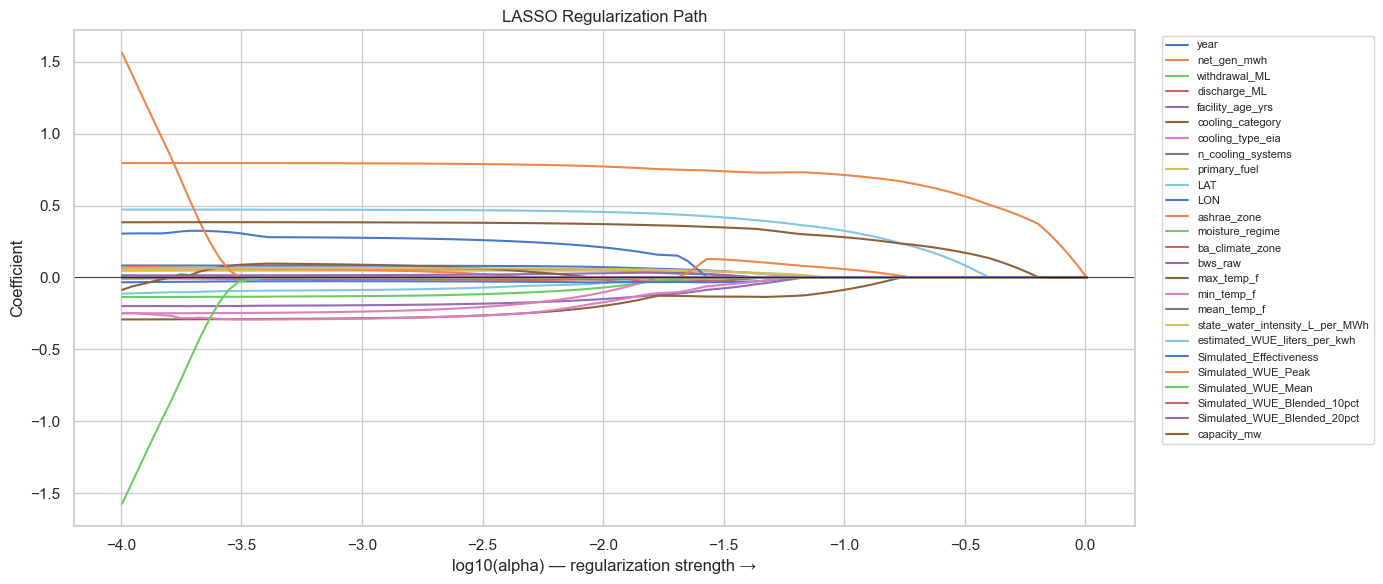

In [14]:
# LASSO path
alphas, coefs, _ = lasso_path(X, y, eps=1e-4, n_alphas=100)

fig, ax = plt.subplots(figsize=(14, 6))
for i, name in enumerate(feature_names):
    ax.plot(np.log10(alphas), coefs[i], label=name)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('log10(alpha) — regularization strength →')
ax.set_ylabel('Coefficient')
ax.set_title('LASSO Regularization Path')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
# Cross-validated LASSO to find best alpha and surviving features
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X, y)
print(f'Best alpha (CV): {lasso_cv.alpha_:.6f}')

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_cv.coef_
}).sort_values('coefficient', key=abs, ascending=False)

surviving = coef_df[coef_df['coefficient'] != 0]
zeroed    = coef_df[coef_df['coefficient'] == 0]

print(f'\nSurviving features ({len(surviving)}):')  
print(surviving.to_string(index=False))
print(f'\nZeroed out ({len(zeroed)}):')  
print(zeroed['feature'].tolist())

Best alpha (CV): 0.076579

Surviving features (6):
                     feature  coefficient
                 net_gen_mwh     0.727080
estimated_WUE_liters_per_kwh     0.352731
                 capacity_mw     0.295074
            cooling_category    -0.114097
          Simulated_WUE_Peak     0.073885
                primary_fuel     0.007568

Zeroed out (20):
['facility_age_yrs', 'year', 'discharge_ML', 'withdrawal_ML', 'LAT', 'n_cooling_systems', 'cooling_type_eia', 'LON', 'bws_raw', 'ashrae_zone', 'moisture_regime', 'ba_climate_zone', 'mean_temp_f', 'min_temp_f', 'max_temp_f', 'state_water_intensity_L_per_MWh', 'Simulated_Effectiveness', 'Simulated_WUE_Mean', 'Simulated_WUE_Blended_10pct', 'Simulated_WUE_Blended_20pct']


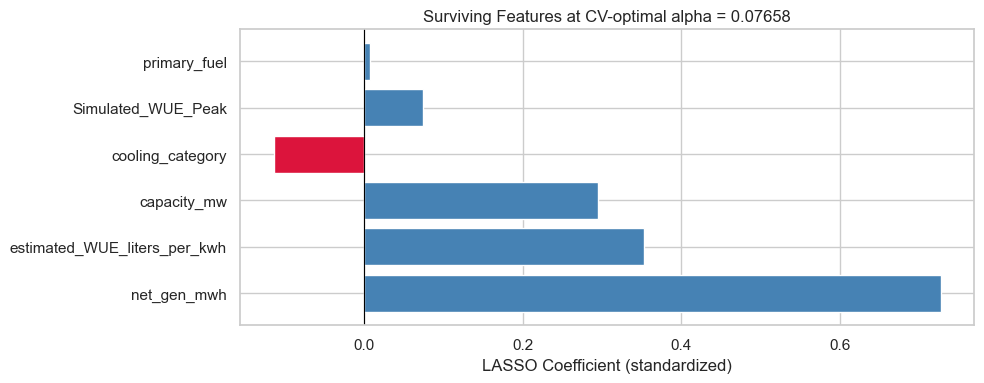

In [16]:
# Bar chart of surviving coefficients
fig, ax = plt.subplots(figsize=(10, max(4, len(surviving) * 0.4)))
colors = ['steelblue' if c > 0 else 'crimson' for c in surviving['coefficient']]
ax.barh(surviving['feature'], surviving['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LASSO Coefficient (standardized)')
ax.set_title(f'Surviving Features at CV-optimal alpha = {lasso_cv.alpha_:.5f}')
plt.tight_layout()
plt.show()

---
## 7. Feature Reduction Summary

Combine evidence from correlation, VIF, Kruskal-Wallis, and LASSO to produce a recommended final feature set.

In [17]:
# Summary table: correlation with target, VIF, KW significance, LASSO survived
summary = pd.DataFrame({'feature': feature_names})

# Pearson correlation with target
pearson_target = {}
for col in feature_names:
    try:
        pearson_target[col] = df[col].corr(log_cons)
    except Exception:
        pearson_target[col] = np.nan
summary['pearson_r'] = summary['feature'].map(pearson_target).round(3)

# VIF
vif_map = dict(zip(vif_results['feature'], vif_results['VIF'].round(1)))
summary['VIF'] = summary['feature'].map(vif_map)

# LASSO coefficient
lasso_map = dict(zip(coef_df['feature'], coef_df['coefficient'].round(4)))
summary['lasso_coef'] = summary['feature'].map(lasso_map)
summary['lasso_survived'] = summary['lasso_coef'] != 0

summary = summary.sort_values('lasso_survived', ascending=False)
print(summary.to_string(index=False))

                        feature  pearson_r       VIF  lasso_coef  lasso_survived
                    capacity_mw      0.384      10.8      0.2951            True
               cooling_category        NaN       NaN     -0.1141            True
             Simulated_WUE_Peak      0.157       inf      0.0739            True
                   primary_fuel        NaN       NaN      0.0076            True
   estimated_WUE_liters_per_kwh     -0.573       1.5      0.3527            True
                    net_gen_mwh      0.373       6.6      0.7271            True
                     max_temp_f      0.369 1095280.7     -0.0000           False
    Simulated_WUE_Blended_20pct      0.156       inf      0.0000           False
    Simulated_WUE_Blended_10pct      0.156       inf      0.0000           False
             Simulated_WUE_Mean      0.156       inf      0.0000           False
        Simulated_Effectiveness      0.155   30860.5      0.0000           False
state_water_intensity_L_per_

In [18]:
# Final recommended features based on all evidence
# Update this list after reviewing the outputs above
FINAL_FEATURES = surviving['feature'].tolist()
print('Recommended feature set for modeling:')
for f in FINAL_FEATURES:
    print(f'  {f}')
print(f'\nTotal: {len(FINAL_FEATURES)} features')

Recommended feature set for modeling:
  net_gen_mwh
  estimated_WUE_liters_per_kwh
  capacity_mw
  cooling_category
  Simulated_WUE_Peak
  primary_fuel

Total: 6 features
